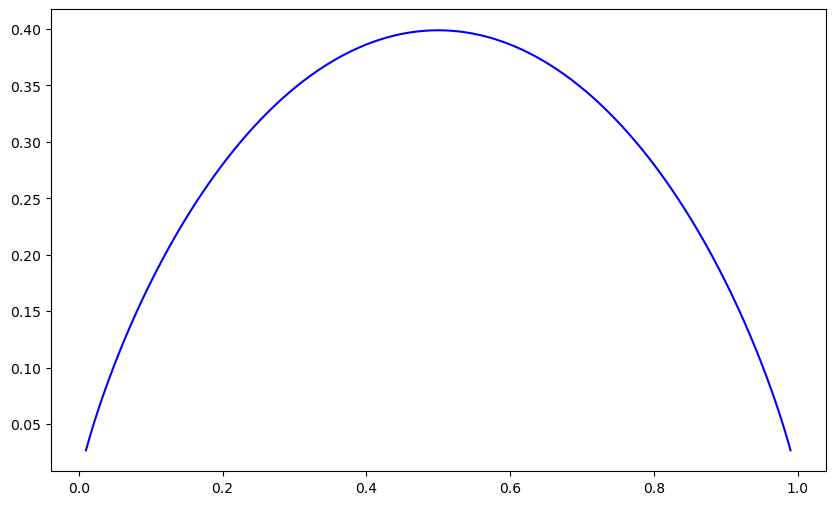

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置α的范围（0.01到0.99，避免端点数值问题）
alpha = np.linspace(0.01, 0.99, 500)

# 计算函数值
phi = norm.pdf(norm.ppf(alpha))  # φ(Φ⁻¹(α))
plt.figure(figsize = (10,6))
plt.plot(alpha, phi, label=r'$\phi(\Phi^{-1}(\alpha))$', color='blue')

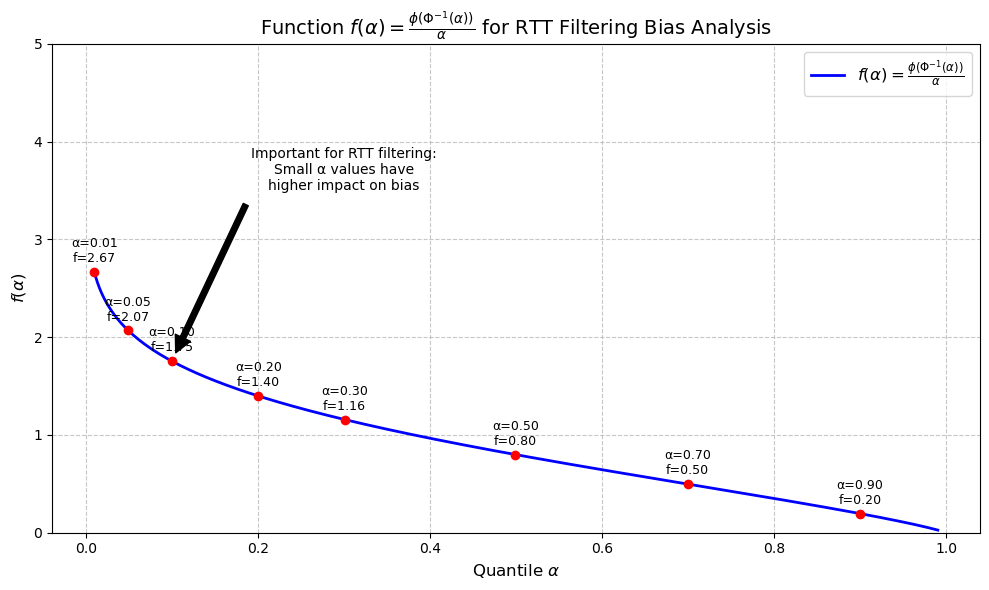

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 设置α的范围（0.01到0.99，避免端点数值问题）
alpha = np.linspace(0.01, 0.99, 500)

# 计算函数值
phi = norm.pdf(norm.ppf(alpha))  # φ(Φ⁻¹(α))
f_alpha = phi / alpha

# 创建图形
plt.figure(figsize=(10, 6))

# 绘制函数曲线
plt.plot(alpha, f_alpha, 'b-', linewidth=2, label=r'$f(\alpha) = \frac{\phi(\Phi^{-1}(\alpha))}{\alpha}$')

# 标记关键点
critical_points = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 0.9]
for a in critical_points:
    idx = np.abs(alpha - a).argmin()
    plt.plot(alpha[idx], f_alpha[idx], 'ro')
    plt.text(alpha[idx], f_alpha[idx] + 0.1, f'α={a:.2f}\nf={f_alpha[idx]:.2f}', 
             ha='center', fontsize=9)

# 添加说明和标签
plt.title(r'Function $f(\alpha) = \frac{\phi(\Phi^{-1}(\alpha))}{\alpha}$ for RTT Filtering Bias Analysis', fontsize=14)
plt.xlabel(r'Quantile $\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

# 设置坐标轴范围
plt.ylim(0, 5)  # 限制y轴范围以便清晰查看重要区域

# 添加注释说明
plt.annotate('Important for RTT filtering:\nSmall α values have\nhigher impact on bias', 
             xy=(0.1, f_alpha[np.abs(alpha - 0.1).argmin()]), 
             xytext=(0.3, 3.5), 
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, ha='center')

# 显示图形
plt.tight_layout()
plt.show()



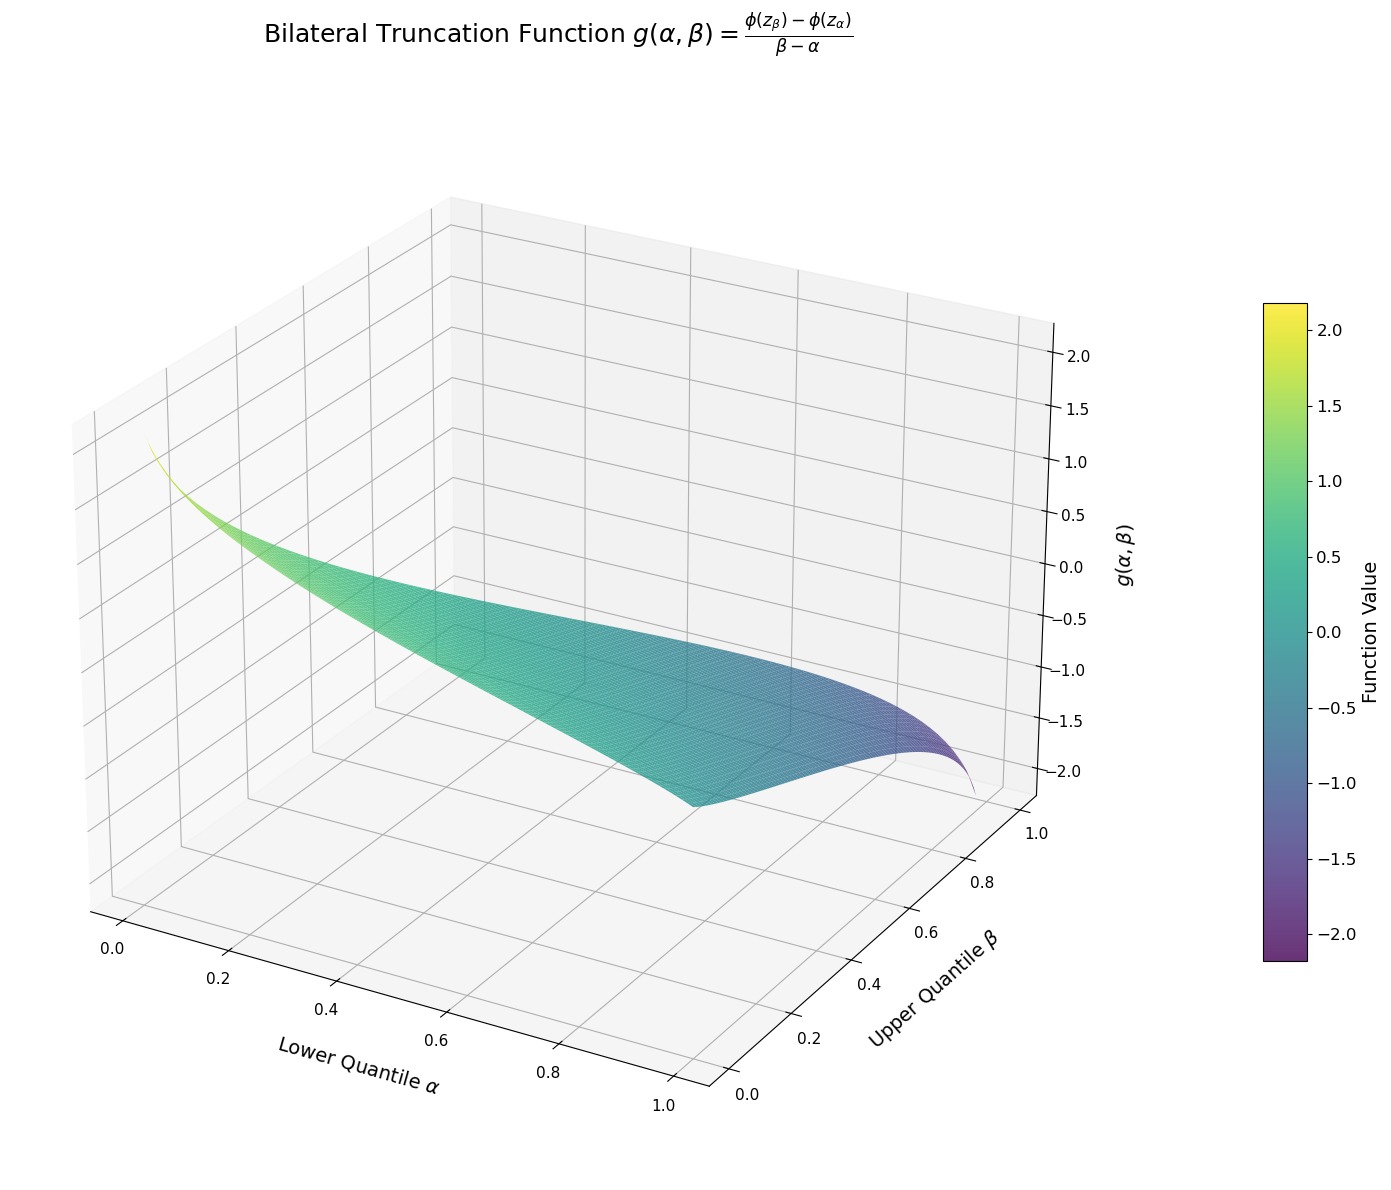

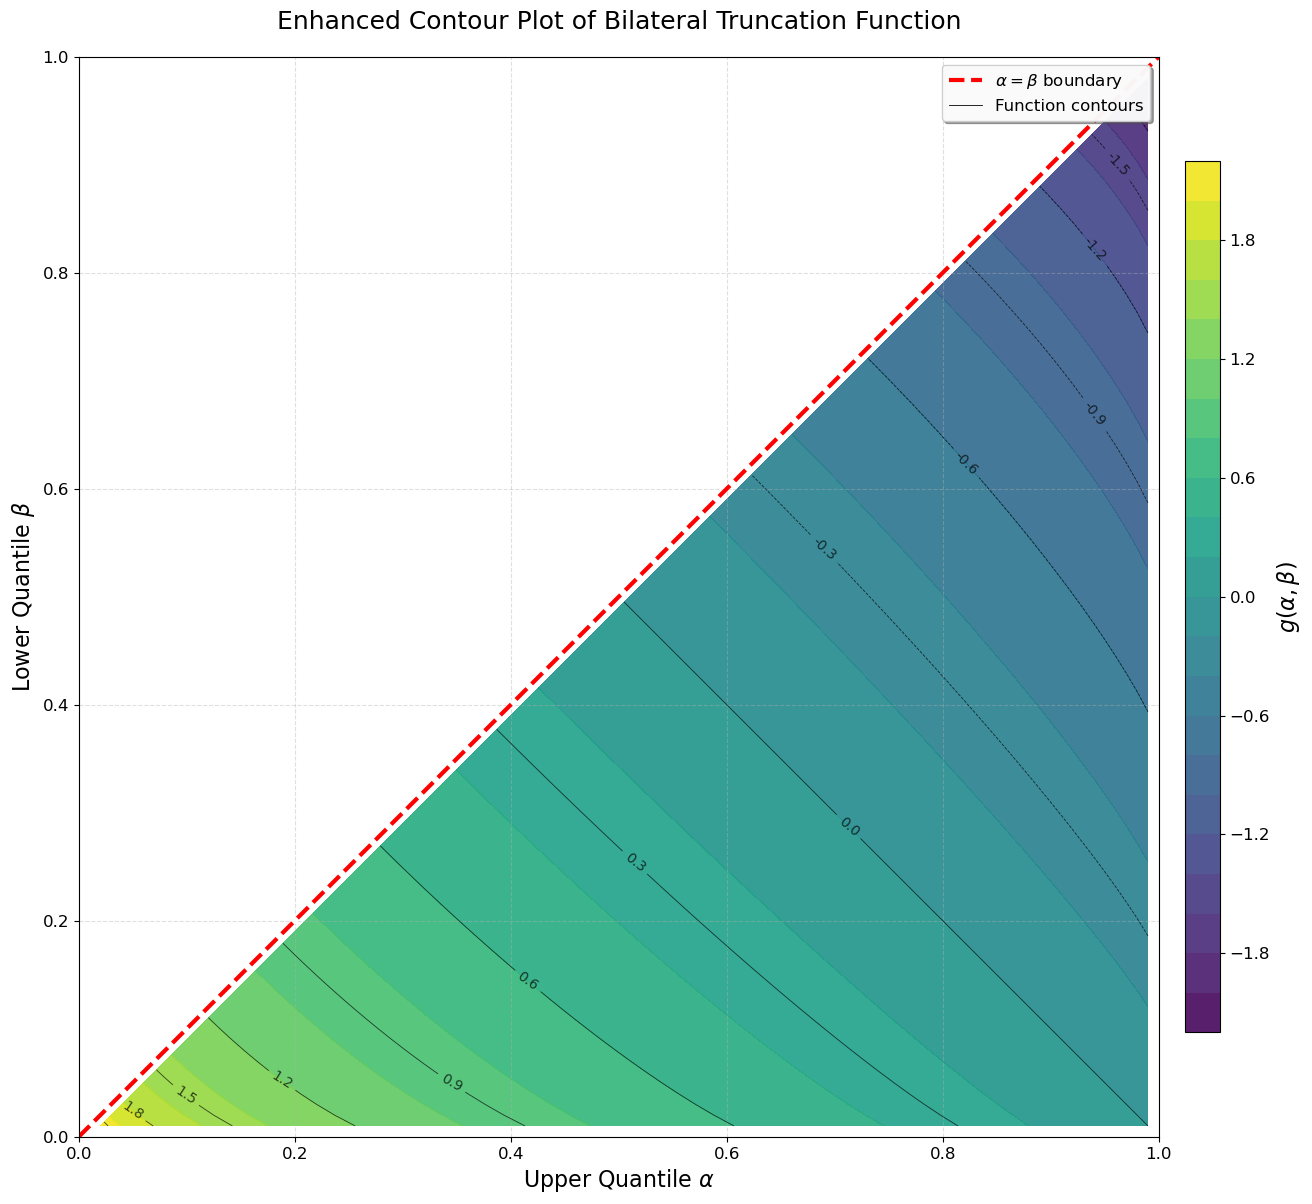

双边截断函数分析结果
函数统计信息:
----------------------------------------
函数值范围: [-2.1778, 2.1778]
平均值: 0.0000
标准差: 0.6082
有效数据点数: 4,950

最大值位置: α=0.020, β=0.010, g=2.1778
最小值位置: α=0.990, β=0.980, g=-2.1778


In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 创建网格
alpha = np.linspace(0.01, 0.99, 100)
beta = np.linspace(0.01, 0.99, 100)
Alpha, Beta = np.meshgrid(alpha, beta)

# 初始化结果矩阵
G = np.full(Alpha.shape, np.nan)

# 计算函数值 (仅当 β < α 时)
for i in range(len(alpha)):
    for j in range(len(beta)):
        if Beta[j, i] < Alpha[j, i]:
            z_alpha = norm.ppf(Alpha[j, i])
            z_beta = norm.ppf(Beta[j, i])
            phi_alpha = norm.pdf(z_alpha)
            phi_beta = norm.pdf(z_beta)
            G[j, i] = (phi_beta - phi_alpha) / (Beta[j, i] - Alpha[j, i])

# ========= 3D曲面图 (独立绘制) =========
fig = plt.figure(figsize=(16, 12))
ax1 = fig.add_subplot(111, projection='3d')

surf = ax1.plot_surface(Alpha, Beta, G, cmap=cm.viridis, 
                       rstride=1, cstride=1, alpha=0.8,
                       linewidth=0, antialiased=True)

# 添加标签
ax1.set_title(r'Bilateral Truncation Function $g(\alpha, \beta) = \frac{\phi(z_\beta) - \phi(z_\alpha)}{\beta - \alpha}$', 
              fontsize=18, pad=30)
ax1.set_xlabel(r'Lower Quantile $\alpha$', fontsize=14, labelpad=15)
ax1.set_ylabel(r'Upper Quantile $\beta$', fontsize=14, labelpad=15)
ax1.set_zlabel(r'$g(\alpha, \beta)$', fontsize=14, labelpad=15)

# 添加颜色条
cbar = fig.colorbar(surf, ax=ax1, shrink=0.6, aspect=15, pad=0.1)
cbar.set_label('Function Value', fontsize=14)
cbar.ax.tick_params(labelsize=12)

# 调整视角以获得更好的观察效果
ax1.view_init(elev=25, azim=-60)

# 设置坐标轴刻度标签大小
ax1.tick_params(axis='x', labelsize=11)
ax1.tick_params(axis='y', labelsize=11)
ax1.tick_params(axis='z', labelsize=11)

plt.tight_layout()
plt.show()

# ========= 等高线图 (独立绘制) =========
fig, ax2 = plt.subplots(figsize=(14, 12))

# 1. 填充颜色背景
contour = ax2.contourf(Alpha, Beta, G, levels=25, cmap=cm.viridis, alpha=0.9)

# 2. 绘制所有细线等高线作为参考
contour_lines = ax2.contour(Alpha, Beta, G, 15, colors='black', linewidths=0.6, alpha=0.7)
ax2.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.1f', colors='black')

# 3. 添加对角线 (α = β) - 使用更醒目的样式
ax2.plot([0, 1], [0, 1], 'white', linewidth=4, alpha=0.9)
ax2.plot([0, 1], [0, 1], 'red', linewidth=3, linestyle='--', alpha=1.0)

# 4. 添加颜色条
cbar = fig.colorbar(contour, ax=ax2, shrink=0.8, aspect=25, pad=0.02)
cbar.set_label(r'$g(\alpha, \beta)$', fontsize=16)
cbar.ax.tick_params(labelsize=12)

# 5. 设置图表标题和标签
ax2.set_title('Enhanced Contour Plot of Bilateral Truncation Function', fontsize=18, pad=20)
ax2.set_xlabel(r'Upper Quantile $\alpha$', fontsize=16)
ax2.set_ylabel(r'Lower Quantile $\beta$', fontsize=16)
ax2.grid(True, linestyle='--', alpha=0.4)

# 6. 创建图例
legend_elements = [
    Line2D([0], [0], color='red', lw=3, linestyle='--', label=r'$\alpha = \beta$ boundary'),
    Line2D([0], [0], color='black', lw=0.6, label='Function contours')
]

ax2.legend(handles=legend_elements, loc='upper right', fontsize=12, 
          framealpha=0.95, fancybox=True, shadow=True)

# 7. 设置坐标轴范围和比例
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.set_aspect('equal')

# 设置坐标轴刻度标签大小
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

# ========= 输出分析结果 =========
print("=" * 80)
print("双边截断函数分析结果")
print("=" * 80)

# 输出函数的一些统计信息
valid_mask = ~np.isnan(G)
if np.any(valid_mask):
    print("函数统计信息:")
    print("-" * 40)
    print(f"函数值范围: [{np.nanmin(G):.4f}, {np.nanmax(G):.4f}]")
    print(f"平均值: {np.nanmean(G):.4f}")
    print(f"标准差: {np.nanstd(G):.4f}")
    print(f"有效数据点数: {np.sum(valid_mask):,}")
    
    # 找到最大值和最小值的位置
    max_idx = np.unravel_index(np.nanargmax(G), G.shape)
    min_idx = np.unravel_index(np.nanargmin(G), G.shape)
    
    max_alpha = Alpha[max_idx]
    max_beta = Beta[max_idx]
    min_alpha = Alpha[min_idx]
    min_beta = Beta[min_idx]
    
    print(f"\n最大值位置: α={max_alpha:.3f}, β={max_beta:.3f}, g={np.nanmax(G):.4f}")
    print(f"最小值位置: α={min_alpha:.3f}, β={min_beta:.3f}, g={np.nanmin(G):.4f}")

print("=" * 80)

已加载上行配置: 8 个高斯分量
已加载下行配置: 8 个高斯分量
--- 正在生成 2,000,000 个基础样本用于分析 ---
--- 基础样本生成完毕 ---

--- 基准分析 (完全不过滤) ---
估计器的固有偏差 (E[0.5 * (d_ms - d_sm)]): 10.2294 μs


--- 开始一维偏差与方差分析 (单边过滤) ---


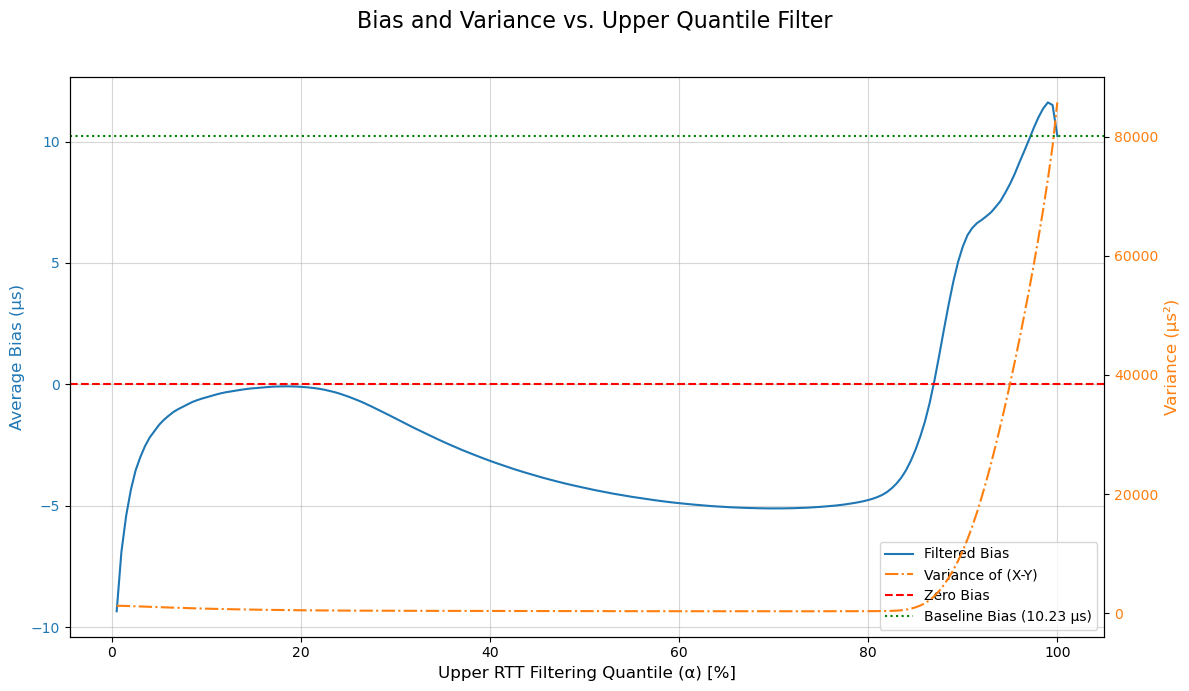


--- 开始二维偏差分析 (双边过滤) ---
--- 二维偏差数据计算完成，开始绘图 ---
--- 二维偏差数据计算完成，开始绘图 ---


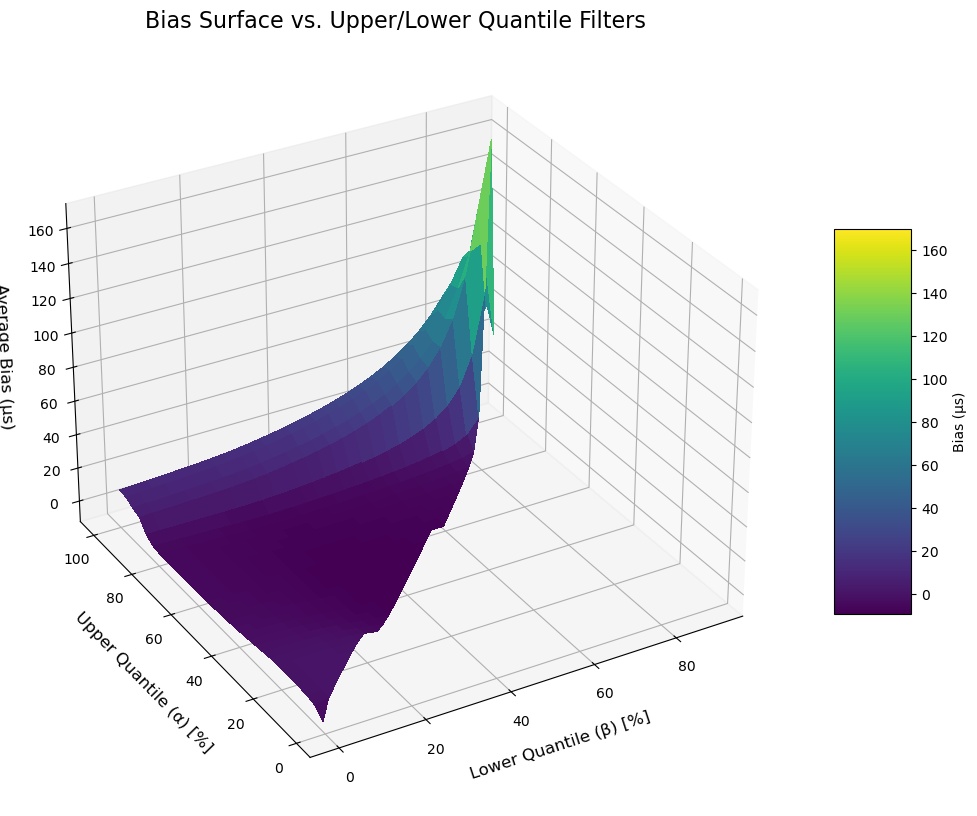

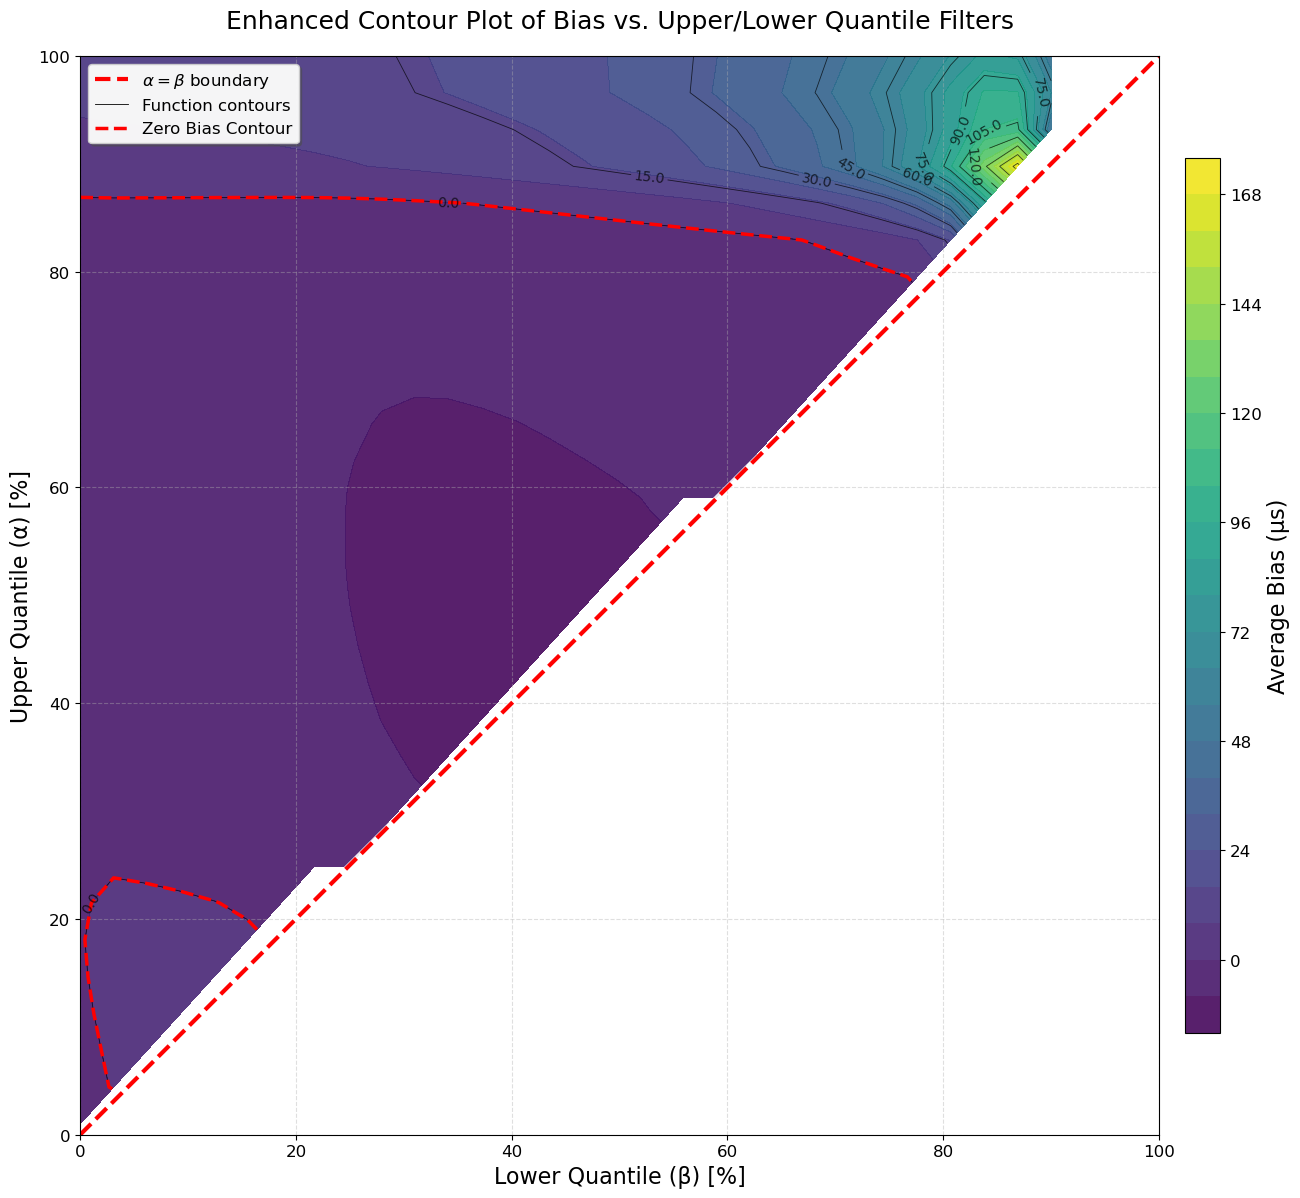

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import json
import os

# --- 0. 从JSON文件加载模型配置 ---

# 从指定的JSON文件加载参数
uplink_path = r'C:\Git_Code\Clock_Sync\results\load_analysis_lsq\gmm_params\gmm_params_上行delay_100.json'
downlink_path = r'C:\Git_Code\Clock_Sync\results\load_analysis_lsq\gmm_params\gmm_params_下行delay_100.json'

# 检查文件是否存在
if not os.path.exists(uplink_path):
    raise FileNotFoundError(f"上行文件未找到: {uplink_path}")
if not os.path.exists(downlink_path):
    raise FileNotFoundError(f"下行文件未找到: {downlink_path}")

# 加载上行延迟参数 (d_ms)
with open(uplink_path, 'r', encoding='utf-8') as f:
    uplink_config = json.load(f)

# 加载下行延迟参数 (d_sm)
with open(downlink_path, 'r', encoding='utf-8') as f:
    downlink_config = json.load(f)

print(f"已加载上行配置: {uplink_config['n_components']} 个高斯分量")
print(f"已加载下行配置: {downlink_config['n_components']} 个高斯分量")

def create_gmm_from_config(config):
    """从JSON配置创建高斯混合模型"""
    n_components = config['n_components']
    gmm = GaussianMixture(n_components=n_components, random_state=0)
    gmm.weights_ = np.array(config['weights'])
    gmm.means_ = np.array(config['means']).reshape(-1, 1)
    gmm.covariances_ = np.array(config['covariances']).reshape(-1, 1, 1)
    gmm.precisions_cholesky_ = np.linalg.cholesky(np.linalg.inv(gmm.covariances_)).transpose((0, 2, 1))
    return gmm

# 创建GMM模型
d_ms_dist = create_gmm_from_config(uplink_config)
d_sm_dist = create_gmm_from_config(downlink_config)

def sample_delays(gmm, n_samples, log_transformed=True):
    """从GMM采样延迟，并根据配置处理对数变换"""
    samples, _ = gmm.sample(n_samples)
    if log_transformed:
        samples = np.exp(samples)
    return samples.flatten()

# --- 1. 生成用于分析的基础样本数据 ---

def generate_base_samples(n_simulation=2_000_000):
    """生成用于所有后续离线分析的大量基础样本数据。"""
    print(f"--- 正在生成 {n_simulation:,} 个基础样本用于分析 ---")
    d_ms_samples = sample_delays(d_ms_dist, n_simulation, uplink_config.get('log_transformed', False))
    d_sm_samples = sample_delays(d_sm_dist, n_simulation, downlink_config.get('log_transformed', False))
    rtt_samples = d_ms_samples + d_sm_samples
    true_bias_term_samples = 0.5 * (d_ms_samples - d_sm_samples)
    print("--- 基础样本生成完毕 ---")
    return rtt_samples, true_bias_term_samples
    
# --- 2. 一维偏差与方差分析 (保留不变) ---

def analyze_and_plot_1d_bias_variance(rtt_samples, true_bias_term_samples, baseline_bias):
    """执行单边过滤 (RTT <= r_alpha) 的偏差和方差分析并绘图。"""
    print("\n--- 开始一维偏差与方差分析 (单边过滤) ---")
    alphas = np.linspace(0.005, 1.0, 200)
    estimated_biases = []
    estimated_variances = []

    for alpha in alphas:
        rtt_threshold = np.quantile(rtt_samples, alpha)
        mask = rtt_samples <= rtt_threshold
        filtered_bias_terms = true_bias_term_samples[mask]
        conditional_bias = np.mean(filtered_bias_terms)
        estimated_biases.append(conditional_bias)
        conditional_variance = 4 * np.var(filtered_bias_terms)
        estimated_variances.append(conditional_variance)

    fig, ax1 = plt.subplots(figsize=(12, 7))
    color1 = 'tab:blue'
    ax1.set_xlabel('Upper RTT Filtering Quantile (α) [%]', fontsize=12)
    ax1.set_ylabel('Average Bias (μs)', fontsize=12, color=color1)
    line1, = ax1.plot(alphas * 100, estimated_biases, color=color1, label='Filtered Bias')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.5)
    line2 = ax1.axhline(0, color='red', linestyle='--', label='Zero Bias')
    line3 = ax1.axhline(baseline_bias, color='green', linestyle=':', 
                        label=f'Baseline Bias ({baseline_bias:.2f} μs)')
    ax2 = ax1.twinx()
    color2 = 'tab:orange'
    ax2.set_ylabel('Variance (μs²)', fontsize=12, color=color2)
    line4, = ax2.plot(alphas * 100, estimated_variances, color=color2, linestyle='-.', label='Variance of (X-Y)')
    ax2.tick_params(axis='y', labelcolor=color2)
    lines = [line1, line4, line2, line3]
    ax1.legend(lines, [l.get_label() for l in lines], loc='best')
    fig.suptitle('Bias and Variance vs. Upper Quantile Filter', fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# --- 3. 二维偏差分析 (双边过滤) ---

def analyze_and_plot_2d_bias(rtt_samples, true_bias_term_samples, grid_size=30):
    """执行双边过滤 (r_beta <= RTT <= r_alpha) 的偏差分析并生成3D图和等高线图。"""
    print("\n--- 开始二维偏差分析 (双边过滤) ---")
    
    betas = np.linspace(0.0, 0.9, grid_size)
    alphas = np.linspace(0.01, 1.0, grid_size)
    B, A = np.meshgrid(betas, alphas)
    Z_bias = np.full(B.shape, np.nan)

    for i in range(grid_size):
        for j in range(grid_size):
            beta, alpha = B[i, j], A[i, j]
            if alpha <= beta: continue
            
            rtt_lower = np.quantile(rtt_samples, beta)
            rtt_upper = np.quantile(rtt_samples, alpha)
            mask = (rtt_samples >= rtt_lower) & (rtt_samples <= rtt_upper)
            if not np.any(mask): continue
            
            Z_bias[i, j] = np.mean(true_bias_term_samples[mask])
            
    print("--- 二维偏差数据计算完成，开始绘图 ---")

    # --- 绘制3D曲面图 (已改回原始版本) ---
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(B * 100, A * 100, Z_bias, cmap=cm.viridis,
                           linewidth=0, antialiased=False)
    ax.set_xlabel('Lower Quantile (β) [%]', fontsize=12, labelpad=10)
    ax.set_ylabel('Upper Quantile (α) [%]', fontsize=12, labelpad=10)
    ax.set_zlabel('Average Bias (μs)', fontsize=12, labelpad=10)
    ax.set_title('Bias Surface vs. Upper/Lower Quantile Filters', fontsize=16)
    fig.colorbar(surf, shrink=0.5, aspect=5, label='Bias (μs)')
    ax.view_init(elev=30, azim=-120)
    plt.show()

    # --- 绘制等高线图 (增强版，采用简洁风格) ---
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # 1. 填充颜色背景
    contour = ax.contourf(B * 100, A * 100, Z_bias, levels=25, cmap=cm.viridis, alpha=0.9)
    
    # 2. 绘制所有细线等高线作为参考
    contour_lines = ax.contour(B * 100, A * 100, Z_bias, 15, colors='black', linewidths=0.6, alpha=0.7)
    ax.clabel(contour_lines, inline=True, fontsize=10, fmt='%1.1f', colors='black')
    
    # 3. 高亮零偏差等高线
    ax.contour(B * 100, A * 100, Z_bias, levels=[0], 
               colors='red', linewidths=2.5, linestyles='--')

    # 4. 添加对角线 (α = β) - 使用更醒目的样式
    ax.plot([0, 100], [0, 100], 'white', linewidth=4, alpha=0.9)
    ax.plot([0, 100], [0, 100], 'red', linewidth=3, linestyle='--', alpha=1.0)

    # 5. 添加颜色条
    cbar = fig.colorbar(contour, ax=ax, shrink=0.8, aspect=25, pad=0.02)
    cbar.set_label('Average Bias (μs)', fontsize=16)
    cbar.ax.tick_params(labelsize=12)
    
    # 6. 创建简洁图例
    legend_elements = [
        Line2D([0], [0], color='red', lw=3, linestyle='--', label=r'$\alpha = \beta$ boundary'),
        Line2D([0], [0], color='black', lw=0.6, label='Function contours'),
        Line2D([0], [0], color='red', lw=2.5, linestyle='--', label='Zero Bias Contour')
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=12, 
             framealpha=0.95, fancybox=True, shadow=True)

    # 7. 设置标签和标题
    ax.set_xlabel('Lower Quantile (β) [%]', fontsize=16)
    ax.set_ylabel('Upper Quantile (α) [%]', fontsize=16)
    ax.set_title('Enhanced Contour Plot of Bias vs. Upper/Lower Quantile Filters', fontsize=18, pad=20)
    ax.grid(True, linestyle='--', alpha=0.4)
    
    # 8. 设置坐标轴范围和比例
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect('equal')
    
    # 设置坐标轴刻度标签大小
    ax.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.show()

# --- 主程序入口 ---
if __name__ == "__main__":
    rtt_samples, bias_samples = generate_base_samples(n_simulation=2_000_000)
    baseline_bias = np.mean(bias_samples)
    print("\n" + "="*50)
    print(f"--- 基准分析 (完全不过滤) ---")
    print(f"估计器的固有偏差 (E[0.5 * (d_ms - d_sm)]): {baseline_bias:.4f} μs")
    print("="*50 + "\n")
    analyze_and_plot_1d_bias_variance(rtt_samples, bias_samples, baseline_bias)
    analyze_and_plot_2d_bias(rtt_samples, bias_samples, grid_size=30)